In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import time as tm
from time import time
import fitsio
import pandas as pd
from galpy.potential import MWPotential2014, vcirc, evaluateRforces
from galpy.orbit import Orbit
from scipy.stats import gaussian_kde
import corner
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

from astroquery.gaia import Gaia
from astropy.table import Table
from astropy.table import Table, vstack
from glob import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LinearRegression
import os
from datetime import datetime
from matplotlib.ticker import AutoLocator

Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST


In [2]:
# Setup and helper functions moved to external module
from plots_for_ASA_cell2 import *

# If you change the external module and want live reload during development, uncomment:
# %load_ext autoreload
# %autoreload 2

In [3]:
Vmans_NGC3201 = pd.read_csv(
    Vmans_NGC3201_txt,
    sep='\t',
    header=0
)
Vmans_NGC3201.columns = Vmans_NGC3201.columns.str.replace('#', '').str.strip()
Vmans_NGC3201_high_prob = Vmans_NGC3201[(Vmans_NGC3201['memberprob'] > 0.99)]# & (Vmans_NGC3201['qflag'] == 0)]





Vmans_NGC5139 = pd.read_csv(
    Vmans_NGC5139_txt,
    sep='\t',
    header=0
)
Vmans_NGC5139.columns = Vmans_NGC5139.columns.str.replace('#', '').str.strip()
Vmans_NGC5139_high_prob = Vmans_NGC5139[(Vmans_NGC5139['memberprob'] > 0.99)]# & (Vmans_NGC5139['qflag'] == 0)]




Vmans_NGC1851 = pd.read_csv(
    Vmans_NGC1851_txt,
    sep='\t',
    header=0
)
Vmans_NGC1851.columns = Vmans_NGC1851.columns.str.replace('#', '').str.strip()
Vmans_NGC1851_high_prob = Vmans_NGC1851[(Vmans_NGC1851['memberprob'] > 0.99)]# & (Vmans_NGC5139['qflag'] == 0)]

In [4]:
with fitsio.FITS(galah_Gaia_fits) as hdul1:
    data_1 = hdul1[1].read()
galah_Gaia_raw = pd.DataFrame(data_1)
galah_Gaia_raw = ensure_native_endian(galah_Gaia_raw)

In [5]:
def NGC3201_cuts_pradosh(df):  # I would need to make some small changes for this to work for galah. really Ijust need to change the RA DEC and Energy to the correct column name
      return((152 < df['RA']) & (156 > df['RA']) & (-48 < df['DEC']) & (-45 > df['DEC']) & (2000 > df['Energy']) & (-2500 > df['jphi']))
     
def Sequoia_cuts_Diane_2021(df):
    return (-1.0< df['jphi']/df['jtot']) & (df['jphi']/df['jtot']<-0.6) & (-1.0 < (df['jz'] - df['jr'])/df['jtot']) & (-1.0 < (df['jz'] - df['jr'])/df['jtot']) & (0.1 > (df['jz'] - df['jr'])/df['jtot'])

def GSE_cuts_Diane_2021(df):
        return (-500< df['jphi']) & (500 > df['jphi']) & (30 < np.sqrt(df['jr'])) & (55 > np.sqrt(df['jr']))

In [6]:
galah_Gaia = galah_Gaia_raw[(galah_Gaia_raw['snr_px_ccd3'] > 30)       # Kushniruk 2026 also has cuts in log g and temp. I wonder if I should as well
                        & (galah_Gaia_raw['flag_sp'] == 0)
                        & (galah_Gaia_raw['flag_fe_h'] == 0)
                        & (galah_Gaia_raw['e_fe_h'] < 0.2)
                        & (galah_Gaia_raw['flag_sp_fit'] == 0)
                        & (galah_Gaia_raw['flag_red'] == 0)
                        & (galah_Gaia_raw['ruwe'] < 1.4)
                        & (galah_Gaia_raw['logg'] < 3.5)
                        & (galah_Gaia_raw['teff'] > 4000)
                        & (galah_Gaia_raw['teff'] < 6500)
                        # & (galah_Gaia_raw['flag_mg_fe'] == 0)
                        # & (galah_Gaia_raw['flag_na_fe'] == 0)
                        # & (galah_Gaia_raw['flag_cu_fe'] == 0)
                        & (galah_Gaia_raw['fe_h'] < -0.75)
                        # & (galah_Gaia_raw['fe_h'] < -0.9)
                        # & (galah_Gaia_raw['ti_fe'] > 0.25)
                        & (galah_Gaia_raw['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main',
                                                               'k2_hermes', 'galah_phase2', 'tess_hermes'
                                                               ]))
    ]

In [ ]:
# NGC5139_Galah = galah_Gaia[(galah_Gaia['ra'] > 201.2)
#                              & (galah_Gaia['ra'] < 202.2) 
#                              & (galah_Gaia['dec'] > -47.8)
#                              & (galah_Gaia['dec'] < -47.2)
#                              & (galah_Gaia['pmra'] < 1)
#                              & (galah_Gaia['pmra'] > -6)
#                              & (galah_Gaia['pmdec'] < -4)
#                              & (galah_Gaia['pmdec'] > -10)
#                              & (galah_Gaia['jphi'] < 0)
#                              ]

# NGC3201_Galah = galah_Gaia[(galah_Gaia['pmra'] > 6.5)
#                             & (galah_Gaia['pmra'] < 10)
#                             & (galah_Gaia['pmdec'] > -3.5)
#                             & (galah_Gaia['pmdec'] < -1)
#                             # & (galah_Gaia['fe_h'] < 0.0)
#                             & (galah_Gaia['ra'] > 152)
#                             & (galah_Gaia['ra'] < 156)
#                             & (galah_Gaia['dec'] > -49)
#                             & (galah_Gaia['dec'] < -44)
#                             & (galah_Gaia['jphi'] < 0)
#                             ]

NGC3201_galah = pd.merge( galah_Gaia, Vmans_NGC3201_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC5139_galah = pd.merge( galah_Gaia, Vmans_NGC5139_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC1851_galah = pd.merge( galah_Gaia, Vmans_NGC1851_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')

galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)
                                 & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                 & (galah_Gaia_raw['flag_mg_fe'] == 0)
                                 & (galah_Gaia_raw['flag_na_fe'] == 0)
                                 & (galah_Gaia_raw['flag_cu_fe'] == 0)
                                 & ((galah_Gaia_raw['mg_fe'] - galah_Gaia_raw['cu_fe']) - ((1.06923) * galah_Gaia_raw['na_fe']) > 0.40150)
                                 ]

# Kushniruk et al . 2026 https://doi.org/10.1051/0004-6361/202451201
galah_Kushniruk_Thamnos1 = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])- 13.5)**2) / (4.0**2)) + (((galah_Gaia['jphi'] + 600)**2) / (350**2)) < 1)
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

galah_Kushniruk_Thamnos2 = galah_Gaia[(((np.sqrt(galah_Gaia['jr'])-8.6)**2) / (3.5**2)) + (((galah_Gaia['jphi'] + 1184)**2) / (175**2)) < 1
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_GSE = galah_Gaia[GSE_cuts_Diane_2021(galah_Gaia)
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            # & (galah_Gaia['fe_h'] < -0.8)
                            ]

galah_Gaia_Sequoia = galah_Gaia[Sequoia_cuts_Diane_2021(galah_Gaia)
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            # & (galah_Gaia['fe_h'] < -0.8)
                            ]

galah_Gaia_Halo = galah_Gaia[(np.sqrt((galah_Gaia['vphi']-230)**2 + (galah_Gaia['vr'])**2 + (galah_Gaia['vz'])**2) > 230) # Koppelman et al. 2019  https://doi.org/10.1051/0004-6361/201936738
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id'])) 
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id'])) 
                            # & (galah_Gaia['ti_fe'] > 0.25)

                             ]


/tmp/ipykernel_4303/2390465503.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)



In [27]:
element_list_full_galah = ["h", "fe", "n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti" "v", "cr" ,"mn", "co", "ni", "cu", "zn", "rb", "sr", "y", "zr", "mo", "ru", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.
element_list_partial_small_galah_1 = [ 'fe', 'ca', 'ti', 'na', 'mn', 'cu','mg']
element_list_partial_small_galah_2 = [ 'fe', 'ca', 'na', 'mn', 'cu','mg', 'nd']
element_list_partial_small_galah_3 = [ 'cu', 'ca', 'mn', 'ni','v','na', 'nd']
element_list_partial_small_galah_4 = [ 'cu', 'ca', 'mn', 'ti','v','na', 'nd']
element_list_partial_small_galah_5 = [ 'cu', 'ca', 'mn', 'ti','ba','na', 'nd']
element_list_partial_small_galah_6 = [ 'cu', 'ca', 'mn', 'ti', 'v', 'ba','na', 'nd']
element_list_partial_small_galah_7 = [ 'fe', 'cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_2 = ['cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_8 = [ 'ca', 'mn', 'y', 'v', 'na', 'nd', 'cr', 'sc']
element_list_partial_small_galah_9 = [ 'cu', 'ca', 'mn', 'ti', 'sc', 'v', 'na', 'nd']
elements_in_Pradosh_Galah_1 = ['ca', 'ti', 'ni','zr', 'ce', 'nd']
elements_in_Pradosh_Galah_2 = ['ca', 'ti', 'ni', 'nd']

element_list = element_list_partial_small_galah_7
element_list = elements_in_Pradosh_Galah_1

galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia, element_list)

galah_Gaia_new_ratios = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from galah but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
galah_gaia_new_element_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
galah_gaia_new_element_ratio_errors_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_GSE, element_list)
galah_Gaia_GSE_new_ratios = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_GSE, element_list)
galah_Gaia_Kushniruk_GSE_new_ratios = galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia, element_list)
galah_Gaia_Sequoia_new_ratios = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC3201_galah, element_list)
galah_Gaia_NGC3201_new_ratios = galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC5139_galah, element_list)
galah_Gaia_NGC5139_new_ratios = galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos1, element_list)
galah_Gaia_Thamnos1_new_ratios = galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos2, element_list)
galah_Gaia_Thamnos2_new_ratios = galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC1851_galah, element_list)
galah_Gaia_NGC1851_new_ratios = galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Halo, element_list)
galah_Gaia_Halo_new_ratios = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

In [28]:
print(len(galah_Gaia_Sequoia_new_ratios))
print(len(galah_Gaia_GSE_new_ratios))
print(len(galah_Gaia_Halo_new_ratios))

18
166
600


In [33]:
Halo_Pradosh_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)
                                            & (galah_Gaia_new_ratios['ti_fe'] > 0.25)
                                            & (galah_Gaia_new_ratios['Lz'] > -1500)
                                            & (galah_Gaia_new_ratios['Lz'] < 1500)
                                            & (galah_Gaia_new_ratios['ecc_gaia'] > 0.5)
                                            & (galah_Gaia_new_ratios['ecc_gaia'] < 0.8)
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE_new_ratios['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia_new_ratios['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]

thickdisk_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)
                                                 & (galah_Gaia_new_ratios['ti_fe'] > 0.25)
                                                 & (galah_Gaia_new_ratios['Lz'] > 0)
                                                 & (galah_Gaia_new_ratios['ecc_gaia'] < 0.5)
                                                #  & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE_new_ratios['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia_new_ratios['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]

/tmp/ipykernel_4303/1565538047.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Halo_Pradosh_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)

/tmp/ipykernel_4303/1565538047.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  thickdisk_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)



In [ ]:
''' THESE INCLUDE [ 'cu', 'ca', 'mn', 'ti','ba','na', 'nd'] and 4d '''
'''  GSE_vs_Sequoia and Halo_vs_GS_vs_Sequoia '''

# previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260520_012632_Galah_GSE_vs_Sequoia_vs_Halo_4d_cu_ca_mn_ti_ba_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'

# previos_values_lcation_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)

# previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260520_153001_Galah_Halo_vs_GS_vs_Sequoia_4d_cu_ca_mn_ti_ba_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'

# previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)

In [ ]:
''' THESE INCLUDE [ 'cu', 'ca', 'mn', 'ti', 'v', 'na', 'nd'] and 4d '''
'''  GSE_vs_Sequoia and Halo_vs_GS_vs_Sequoia '''

# previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260521_182738_Galah_GSE_vs_Sequoia_4d_cu_ca_mn_ti_V_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'

# previos_values_lcation_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)

# previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260521_152626_Galah_Halo_vs_GSE_vs_Sequoia_4d_cu_ca_mn_ti_V_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'

# previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)

In [ ]:
''' THESE INCLUDE [ 'cu', 'ca', 'mn', 'ti', 'v', 'ba', 'na', 'nd'] and 3d '''
'''  GSE_vs_Sequoia and Halo_vs_GS_vs_Sequoia '''

previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260522_134626_Galah_GSE_vs_Sequoia_3d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'
previos_values_lcation_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)
p1_low = 0.875

previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260522_153935_Galah_Halo_vs_GSE_vs_Sequoia_3d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'
previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)
p2_low = 0.765


In [ ]:
''' THESE INCLUDE [ 'cu', 'ca', 'mn', 'ti','v', 'ba', 'na', 'nd'] and 4d '''
'''  GSE_vs_Sequoia and Halo_vs_GS_vs_Sequoia and Halo_vs_Sequoia'''

previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260523_180437_Galah_GSE_vs_Sequoia_4d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'
previos_values_lcation_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)
p1_low = 0.884

previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260523_092132_Galah_Halo_vs_GSE_vs_Sequoia_4d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'
previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)
p2_low = 0.771

# previos_values_lcation_Halo_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260526_074629_Galah_Halo_vs_Sequoia_4d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'
# previos_values_lcation_Halo_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_Halo_vs_Sequoia)

# # first_Q = ((p_value_comparison['accuracy_GSE_Sequoia'] > 0.884) & (p_value_comparison['accuracy_all_3'] > 0.771))

In [ ]:
''' THESE INCLUDE [ 'cu', 'ca', 'mn', 'ti', 'v', 'ba', 'na', 'nd'] and 3d '''
''' THAMNOS Stars were not removed'''
'''  GSE_vs_Sequoia and Halo_vs_GS_vs_Sequoia '''

previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260527_154754_Galah_GSE_vs_Sequoia_3d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75_Thamnos_Stars_kept/full_csv.csv'

previos_values_lcation_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)

previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260527_205216_Galah_Halo_vs_GSE_vs_Sequoia_3d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75_Thamnos_Stars_kept/full_csv.csv'

previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)

In [ ]:
''' THESE INCLUDE [ 'cu', 'ca', 'mn', 'ti', 'v', 'ba', 'na', 'nd'] and 3d '''
''' I wanted to compare the distribution between the two times i ran these elements with and without the thamnos stars theoredically they should be simmilar'''

# previos_values_lcation_GSE_vs_Sequoia= '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260522_134626_Galah_GSE_vs_Sequoia_3d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'

# previos_values_lcation_GSE_vs_Sequoia_raw_no_thamnos  = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)

# previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260527_154754_Galah_GSE_vs_Sequoia_3d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75_Thamnos_Stars_kept/full_csv.csv'

# previos_values_lcation_GSE_vs_Sequoia_raw_with_Thamnos = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)


# previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260522_153935_Galah_Halo_vs_GSE_vs_Sequoia_3d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75/full_csv.csv'

# previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw_no_thamnos = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)

# previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260527_205216_Galah_Halo_vs_GSE_vs_Sequoia_3d_cu_ca_mn_ti_v_ba_na_and_nd_also_fe_is_lessthan_minus0.75_Thamnos_Stars_kept/full_csv.csv'

# previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw_with_thamnos = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)

In [ ]:
''' THESE INCLUDE [ 'cu', 'ca', 'mn', 'ti', 'sc', 'v', 'na', 'nd'] and 3d '''
''' THAMNOS Stars were removed'''
'''  GSE_vs_Sequoia and Halo_vs_GS_vs_Sequoia and Halo vs Sequoia'''

previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260602_140401_Galah_GSE_vs_Sequoia_3d_cu_ca_mn_ti_sc_v_na_and_nd_also_fe_is_lessthan_minus0.75_Thamnos_Stars_removed/full_csv.csv'
previos_values_lcation_GSE_vs_Sequoia_raw  = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)
p1_low = 0.88

# previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260603_123825_Galah_Halo_vs_GSE_vs_Sequoia_3d_cu_ca_mn_ti_sc_v_na_and_nd_also_fe_is_lessthan_minus0.75_Thamnos_Stars_removed/full_csv.csv'
# previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)
# p2_low = 0.765

''' REALY THIS IS HALO VS SEQUOIA BUT I DIDNT WANT TO REWRITE ALL THE VARIABLES'''
previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260605_120535_Galah_Halo_vs_Sequoia_3d_cu_ca_mn_ti_sc_v_na_and_nd_also_fe_is_lessthan_minus0.75_Thamnos_Stars_removed/full_csv.csv'
previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)
p2_low = 0.964



In [29]:
''' THESE INCLUDE elements_in_Pradosh_Galah_1 = ['ca', 'ti', 'ni','zr', 'ce', 'nd'] and 3d '''
''' THAMNOS Stars were removed'''
'''  GSE_vs_Sequoia and Halo vs Sequoia and Halo vs GSE'''

previos_values_lcation_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260626_144743_Galah_GSE_vs_Sequoia_3d_ca_ti_ni_zr_ce_nd_also_fe_is_lessthan_minus0.75_galah_phase_1_2_Hermes/full_csv.csv'
previos_values_lcation_GSE_vs_Sequoia_raw  = pd.read_csv(previos_values_lcation_GSE_vs_Sequoia)
p1_low = 0.85

''' REALY THIS IS HALO VS SEQUOIA BUT I DIDNT WANT TO REWRITE ALL THE VARIABLES'''
previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260626_145557_Galah_Halo_vs_Sequoia_3d_ca_ti_ni_zr_ce_nd_also_fe_is_lessthan_minus0.75_galah_phase_1_2_Hermes/full_csv.csv'
previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)
# p2_low = 0.964

''' REALY THIS IS HALO VS GSE BUT I DIDNT WANT TO REWRITE ALL THE VARIABLES'''
previos_values_lcation_Halo_vs_GSE_vs_Sequoia = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260626_151106_Galah_Halo_vs_GSE_3d_ca_ti_ni_zr_ce_nd_also_fe_is_lessthan_minus0.75_galah_phase_1_2_Hermes/full_csv.csv'
previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw = pd.read_csv(previos_values_lcation_Halo_vs_GSE_vs_Sequoia)
p2_low = 0.77

In [11]:
# match_cols = ['ratio1', 'ratio2', 'ratio3']
# # match_cols = ['ratio1', 'ratio2', 'ratio3', 'ratio4']

# previos_values_lcation_Halo_vs_Sequoia_raw_sorted = (
#     previos_values_lcation_Halo_vs_Sequoia_raw
#     .set_index(match_cols)
#     .loc[previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw.set_index(match_cols).index]
#     .reset_index()
# )

# p_value_comparison = previos_values_lcation_Halo_vs_Sequoia_raw_sorted.merge(
#     previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw[match_cols + ['accuracy']],
#     on=match_cols,
#     suffixes=('_Halo_Sequoia', '_all_3')
# )

# print(p_value_comparison)

# first_Q = ((p_value_comparison['accuracy_Halo_Sequoia'] > 0.964) & (p_value_comparison['accuracy_all_3'] > 0.771))

In [12]:
''' This cell was made so I could compare the times when I included thamnos and when I didn't include thamnos'''

# match_cols = ['ratio1', 'ratio2', 'ratio3']
# match_cols = ['ratio1', 'ratio2', 'ratio3', 'ratio4']

# previos_values_lcation_GSE_vs_Sequoia_raw_sorted_no_thamnos = (
#     previos_values_lcation_GSE_vs_Sequoia_raw_no_thamnos
#     .set_index(match_cols)
#     .loc[previos_values_lcation_GSE_vs_Sequoia_raw_with_Thamnos.set_index(match_cols).index]
#     .reset_index()
# )

# p_value_comparison = previos_values_lcation_GSE_vs_Sequoia_raw_sorted_no_thamnos.merge(
#     previos_values_lcation_GSE_vs_Sequoia_raw_with_Thamnos[match_cols + ['accuracy']],
#     on=match_cols,
#     suffixes=('_GSE_Sequoia', '_all_3')
# )


# previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw_sorted_no_thamnos = (
#     previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw_no_thamnos
#     .set_index(match_cols)
#     .loc[previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw_with_thamnos.set_index(match_cols).index]
#     .reset_index()
# )

# p_value_comparison = previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw_sorted_no_thamnos.merge(
#     previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw_with_thamnos[match_cols + ['accuracy']],
#     on=match_cols,
#     suffixes=('_GSE_Sequoia', '_all_3')
# )

# print(p_value_comparison)

" This cell was made so I could compare the times when I included thamnos and when I didn't include thamnos"

In [13]:
match_cols = ['ratio1', 'ratio2', 'ratio3']
# match_cols = ['ratio1', 'ratio2', 'ratio3', 'ratio4']

previos_values_lcation_GSE_vs_Sequoia_raw_sorted = (
    previos_values_lcation_GSE_vs_Sequoia_raw
    .set_index(match_cols)
    .loc[previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw.set_index(match_cols).index]
    .reset_index()
)

p_value_comparison = previos_values_lcation_GSE_vs_Sequoia_raw_sorted.merge(
    previos_values_lcation_Halo_vs_GSE_vs_Sequoia_raw[match_cols + ['accuracy']],
    on=match_cols,
    suffixes=('_GSE_Sequoia', '_all_3')
    # suffixes=('_G_vs_S', '_H_vs_G')
)

print(p_value_comparison)

    ratio1 ratio2 ratio3  accuracy_GSE_Sequoia  accuracy_all_3
0    zr_ca  nd_ti  nd_ni              0.864865        0.805195
1    ti_ca  ce_ca  ni_ti              0.864865        0.798701
2    zr_ca  nd_ca  nd_zr              0.837838        0.798701
3    zr_ca  nd_ca  nd_ti              0.783784        0.798701
4    ni_ti  zr_ni  nd_ni              0.891892        0.798701
..     ...    ...    ...                   ...             ...
450  nd_ca  ce_ni  nd_ni              0.864865        0.694805
451  ni_ca  nd_ca  nd_ni              0.891892        0.694805
452  ce_ca  nd_ti  nd_ce              0.810811        0.688312
453  nd_ca  nd_ti  ce_ni              0.864865        0.688312
454  zr_ti  ce_ni  nd_zr              0.891892        0.688312

[455 rows x 5 columns]


In [14]:
first_Q = ((p_value_comparison['accuracy_GSE_Sequoia'] > p1_low) & (p_value_comparison['accuracy_all_3'] > p2_low) 
            # & ~((p_value_comparison['accuracy_GSE_Sequoia'] < 0.885) & (p_value_comparison['accuracy_all_3'] < 0.966))
            )

# S_and_A_rank_visual_ratios = ['mn_ca', 'nd_cu', 'v_ti', 'ti_mn', 'v_ca', 'na_mn', 'ca_cu', 'nd_na', 'nd_ca', 'nd_v'] # good without thamnos stars
# ranked_mask = (
#     p_value_comparison['ratio1'].isin(S_and_A_rank_visual_ratios)
#     & p_value_comparison['ratio2'].isin(S_and_A_rank_visual_ratios)
#     & p_value_comparison['ratio3'].isin(S_and_A_rank_visual_ratios)
#     # & p_value_comparison['ratio4'].isin(S_and_A_rank_visual_ratios)
# )


S_and_A_rank_visual_ratios = ['mn_ca', 'nd_cu', 'v_ti', 'ti_mn', 'v_ca', 'na_mn','nd_ti', 'nd_na', 'nd_ca', 'nd_v', 'mn_cu', 'nd_ba'] # good with thamnos stars
ranked_mask = (
    p_value_comparison['ratio1'].isin(S_and_A_rank_visual_ratios)
    & p_value_comparison['ratio2'].isin(S_and_A_rank_visual_ratios)
    & p_value_comparison['ratio3'].isin(S_and_A_rank_visual_ratios)
    # & p_value_comparison['ratio4'].isin(S_and_A_rank_visual_ratios)
)

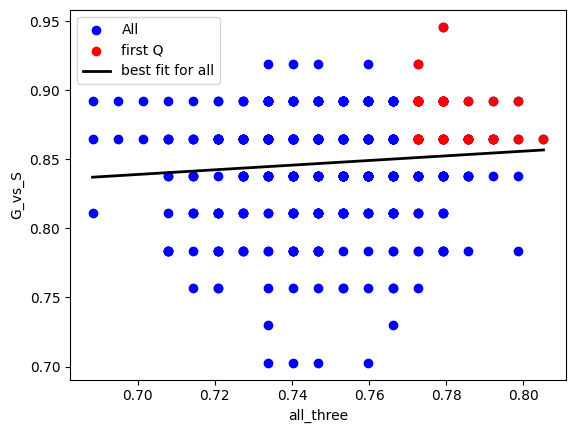

In [15]:
plt.scatter(p_value_comparison['accuracy_all_3'], p_value_comparison['accuracy_GSE_Sequoia'], c  = 'b', label  = 'All')
plt.scatter(p_value_comparison[first_Q]['accuracy_all_3'], p_value_comparison[first_Q]['accuracy_GSE_Sequoia'], c  = 'r', label = 'first Q')
# plt.scatter(p_value_comparison[ranked_mask]['accuracy_all_3'], p_value_comparison[ranked_mask]['accuracy_GSE_Sequoia'], c  = 'g', label = 'visual')

# plt.scatter(p_value_comparison['accuracy_all_3'], p_value_comparison['accuracy_Halo_Sequoia'], c  = 'b', label  = 'first Q')
# plt.scatter(p_value_comparison[first_Q]['accuracy_all_3'], p_value_comparison[first_Q]['accuracy_Halo_Sequoia'], c  = 'r', label = 'all')


x = np.array(p_value_comparison['accuracy_all_3'])
y = np.array(p_value_comparison['accuracy_GSE_Sequoia'])
# fit line
m, b = np.polyfit(x, y, 1)
# line values
y_fit = m * x + b
plt.plot(x, y_fit, label = 'best fit for all', c  = 'black', linewidth = 2)

plt.xlabel('all_three')
plt.ylabel('G_vs_S')
plt.legend()

In [16]:
p_value_comparison[first_Q][0:-1]

,ratio1,ratio2,ratio3,accuracy_GSE_Sequoia,accuracy_all_3
0,zr_ca,nd_ti,nd_ni,0.864865,0.805195
1,ti_ca,ce_ca,ni_ti,0.864865,0.798701
4,ni_ti,zr_ni,nd_ni,0.891892,0.798701
6,ni_ca,zr_ni,nd_ce,0.864865,0.792208
7,zr_ca,nd_ti,nd_ce,0.891892,0.792208
8,zr_ca,ce_ca,ni_ti,0.864865,0.792208
9,zr_ca,ni_ti,ce_ni,0.864865,0.792208
10,ti_ca,zr_ti,nd_ti,0.864865,0.785714
12,ni_ca,ni_ti,nd_ce,0.864865,0.785714
15,ti_ca,zr_ca,ni_ti,0.891892,0.785714


In [19]:
p_value_comparison['ratio 1'] = p_value_comparison['ratio1']
p_value_comparison['ratio 2'] = p_value_comparison['ratio2']
p_value_comparison['ratio 3'] = p_value_comparison['ratio3']

In [20]:
high_acc_mask_table = ratio_totals_table(p_value_comparison[first_Q], galah_gaia_new_element_ratio_list, 3)
high_acc_mask_table

# high_acc_mask = (previos_values_lcation_GSE_vs_Sequoia_raw['accuracy'] > 0.885)
# high_acc_mask_table  = ratio_totals_table(previos_values_lcation_GSE_vs_Sequoia_raw[high_acc_mask], galah_gaia_new_element_ratio_list, 3)
# high_acc_mask_table

,ratio,total
5,ni_ti,30
8,nd_ti,16
2,zr_ca,12
11,nd_ni,12
6,zr_ti,11
0,ti_ca,11
9,zr_ni,9
1,ni_ca,8
14,nd_ce,8
7,ce_ti,6


In [21]:
p_value_comparison[ranked_mask][first_Q]

/tmp/ipykernel_4303/2261801926.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  p_value_comparison[ranked_mask][first_Q]



,ratio1,ratio2,ratio3,accuracy_GSE_Sequoia,accuracy_all_3,ratio 1,ratio 2,ratio 3


In [40]:
''' MINI CORNER PLOTS '''

# e_labels = []
# for i in labels:
#     e_labels.append('e_' + i)
# sample_set = p_value_comparison[first_Q][ranked_mask]
sample_set = p_value_comparison[first_Q]
num = len(sample_set)
print(num)
acc_r = 'accuracy_GSE_Sequoia'
acc_l = 'accuracy_all_3'


TOP_50_ = top_min_corner_plots(sample_set, num)
TOP_lables = min_corner_plot_lables_comparison(sample_set, num, acc_r, acc_l)
parent_folder = "/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_folder = os.path.join(
    parent_folder,
    f"{timestamp}_Galah_scatter_comparison_for_3d_ca_ti_ni_zr_ce_and_nd_also_fe_is_lessthan_minus0.75_between_G_v_S_and_H_v_G_no_vand_hlines_W_Thamnos_Stars_removed"
)                                      # This contains the name of the folder
os.makedirs(save_folder, exist_ok=True)

# Save sample_set to the same folder
sample_set.to_csv(
    os.path.join(save_folder, "full_csv.csv"),
    index=False
)
for i in range(len(TOP_lables[0])):
    labels = TOP_lables[0][i]
    e_labels = TOP_lables[1][i]
    accuracy_1 = TOP_lables[2][i]
    accuracy_2 = TOP_lables[3][i]

    first_plot = 'galah_Gaia_Halo' #pick one of the keys in corner_datasets
    n_components = 2
    vline_and_hline = False

    plot_datapoints=True
    plot_contours=False
    fill_contours=False
    plot_density=False

    corner_datasets = {
        "galah_Gaia_Halo": (galah_Gaia_Halo_new_ratios[labels], galah_Gaia_Halo_new_ratios[e_labels],"grey", 1, 0.8),
        # "galah_Thickdisk": (thickdisk_galah_Gaia[labels], thickdisk_galah_Gaia[e_labels],"purple", 2.5, 1.0),
        "galah_Gaia_GSE": (galah_Gaia_GSE_new_ratios[labels], galah_Gaia_GSE_new_ratios[e_labels],"green", 2.0, 1.0),
        "galah_Gaia_Sequoia": (galah_Gaia_Sequoia_new_ratios[labels], galah_Gaia_Sequoia_new_ratios[e_labels],"red", 2.5, 1.0),
        # "galah_NGC5139": (galah_Gaia_NGC5139_new_ratios[labels], galah_Gaia_NGC5139_new_ratios[e_labels],"blue", 2.5, 1.0),
        # "galah_NGC3201": (galah_Gaia_NGC3201_new_ratios[labels], galah_Gaia_NGC3201_new_ratios[e_labels],"purple", 2.5, 1.0),
    }

    # keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
    # cmap = plt.cm.tab10
    # colors = cmap(np.linspace(0, 0.8, len(keys)))

    # for key, color in zip(keys, colors):
    #     df_values, df_errors, _, ms, alpha = corner_datasets[key]
    #     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
    # # Convert all to values and keep data info

    for key in corner_datasets:
        df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

        vals = df_values.to_numpy()
        # vals, mask = filter_constant_columns(vals)
        errs = df_errors.to_numpy()
        row_mask = np.any(np.isfinite(vals), axis=1)
        vals = vals[row_mask]
        errs = errs[row_mask]
        print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
        corner_datasets[key] = (vals, errs, color, ms, alpha)
    
    first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]

        # Compute reasonable plotting ranges using percentiles
    ranges = []

    for dim in range(first_values.shape[1]):

        # combine all datasets for consistent limits
        combined = []

        for key, (values, errors, color, ms, alpha) in corner_datasets.items():
            combined.append(values[:, dim])

        combined = np.concatenate(combined)

        # remove NaNs/infs
        combined = combined[np.isfinite(combined)]

        # percentile clipping
        low = np.percentile(combined, 3)
        high = np.percentile(combined, 97)

        # optional padding
        padding = 0.05 * (high - low)

        ranges.append((low - padding, high + padding))

    fig = corner.corner(
    first_values,
    labels=labels,
    color=first_color,
    range = ranges,
    data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
    hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
    plot_datapoints=plot_datapoints,
    plot_contours=plot_contours,
    fill_contours=fill_contours,
    plot_density=plot_density,
    )
    ACC_1 = round(accuracy_1, 4)
    ACC_2 = round(accuracy_2, 4)
    fig.suptitle(f'Accuracy: {ACC_1} and {ACC_2}', fontsize=16, y=0.98)
    
    ndim = first_values.shape[1]
    axes = np.array(fig.axes).reshape((ndim, ndim))


    def overlay_gaussian(values, errors, color, n_components):
        for i in range(ndim):
            ax = axes[i, i]
            x = values[:, i]
            sigma_x = errors[:, i]

            mask = np.isfinite(x) & np.isfinite(sigma_x)
            x = x[mask]

            if len(x) > 5:  # need enough points
                # Fit 2-component Gaussian Mixture
                gmm = GaussianMixture(n_components=n_components)
                gmm.fit(x.reshape(-1, 1))

                x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)

                pdf = np.zeros_like(x_grid)



                # Sum the two Gaussians
                for weight, mean, cov in zip(gmm.weights_, gmm.means_, gmm.covariances_):
                    sigma = np.sqrt(cov[0][0])
                    pdf += weight * norm.pdf(x_grid, mean[0], sigma)

                    # (optional) plot individual components
                    ax.plot(x_grid,
                            weight * norm.pdf(x_grid, mean[0], sigma),
                            color=color,
                            lw=1,
                            # ls='dashed',
                            ls = "none",
                            alpha=0.7)

                # Plot total mixture
                ax.plot(x_grid, pdf, color=color, lw=0.5)
                

                #These next couple things will plot the verticle and horizontal lines
                if vline_and_hline == True:
                    max_index = np.argmax(pdf)
                    peak_x = x_grid[max_index]
                    peak_y = pdf[max_index]

                    print("Peak x:", peak_x)
                    print("Peak pdf:", peak_y)

                    # ax.axvline(peak_x, color=color, lw=1)
                    for row in range(ndim):

                        if row >= i:

                            ax_col = axes[row, i]

                            ax_col.axvline(
                                peak_x,
                                color=color,
                                lw=1,
                                alpha=0.8
                            )
                    
                    # draw horizontal line through entire row
                    for col in range(ndim):

                        # lower triangle exists
                        if i >= col:

                            ax_row = axes[i, col]

                            ax_row.axhline(
                                peak_x,
                                color=color,
                                lw=1,
                                alpha=0.8
                            )

    # Overlay remaining datasets
    handles = []
    for key, (values, errors, color, ms, alpha) in corner_datasets.items():
        if key != first_plot:
            corner.corner(
                values,
                fig=fig,
                color=color,
                range = ranges,
                data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
                hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
                plot_datapoints=plot_datapoints,
                plot_contours=plot_contours,
                fill_contours=fill_contours,
                plot_density=plot_density,
                show_titles=(key == "NGC3201"),
            )
            
        overlay_gaussian(values, errors, color, n_components)
        handles.append(plt.Line2D([0], [0], color = color, label = f'{key} N: {values.shape[0]}'))

    fig.legend(handles=handles,
            loc="upper right",
            bbox_to_anchor=(1.0, 0.90),
            #    ncol=len(handles),
            #    frameon=False,
            fontsize=12)
    
    plt.savefig(os.path.join(save_folder, f"plot_{i}_{labels}.png"))

    plt.close()

49
galah_Gaia_Halo: 600 stars, 6 element ratios
galah_Gaia_GSE: 166 stars, 6 element ratios
galah_Gaia_Sequoia: 18 stars, 6 element ratios
galah_Gaia_Halo: 600 stars, 6 element ratios
galah_Gaia_GSE: 166 stars, 6 element ratios
galah_Gaia_Sequoia: 18 stars, 6 element ratios
galah_Gaia_Halo: 600 stars, 6 element ratios
galah_Gaia_GSE: 166 stars, 6 element ratios
galah_Gaia_Sequoia: 18 stars, 6 element ratios
galah_Gaia_Halo: 600 stars, 6 element ratios
galah_Gaia_GSE: 166 stars, 6 element ratios
galah_Gaia_Sequoia: 18 stars, 6 element ratios
galah_Gaia_Halo: 600 stars, 6 element ratios
galah_Gaia_GSE: 166 stars, 6 element ratios
galah_Gaia_Sequoia: 18 stars, 6 element ratios
galah_Gaia_Halo: 600 stars, 6 element ratios
galah_Gaia_GSE: 166 stars, 6 element ratios
galah_Gaia_Sequoia: 18 stars, 6 element ratios
galah_Gaia_Halo: 600 stars, 6 element ratios
galah_Gaia_GSE: 166 stars, 6 element ratios
galah_Gaia_Sequoia: 18 stars, 6 element ratios
galah_Gaia_Halo: 600 stars, 6 element ratios


In [ ]:
labels = ['nd_cu', 'ba_v', 'na_v', 'na_ba']
labels = ['ti_cu', 'nd_cu', 'na_v', 'na_ba'] 

hbvbse = p_value_comparison[(p_value_comparison['ratio1'] == labels[0])
                            & (p_value_comparison['ratio2'] == labels[1])
                            & (p_value_comparison['ratio3'] == labels[2])
                            & (p_value_comparison['ratio4'] == labels[3])
                            ]

In [30]:
# labels = ['ca_cu', 'ba_cu', 'mn_ca']
labels = ['ca_cu', 'mn_ca', 'ba_ca'] #BEST for when Sequoia is more different from the Halo than the GSE
# labels = ['ca_cu', 'v_ca', 'ba_ca']
labels = ['ca_cu', 'ba_ca', 'v_ti'] # 2nd best for when Sequoia is more different from the Halo than the GSE
# labels = ['ba_cu', 'mn_ca', 'ba_ca']
# labels = ['ba_cu', 'ba_ca', 'v_ti']

# labels = ['mn_ca', 'mn_ca', 'v_ti'] 
# labels = [ 'mn_ca', 'ti_mn','v_ti'] # This is a good one with and without thamnos stars
labels = ['mn_ca', 'v_ca', 'nd_ba'] # this is the best with thamnos stars

labels = ['ca_cu', 'v_ca', 'ti_mn']
labels = ['ti_ca', 'ce_ti', 'nd_zr']


# hbvbse = p_value_comparison[(p_value_comparison['ratio1'] == 'ti_cu')
#                             & (p_value_comparison['ratio2'] == 'na_mn')
#                             & (p_value_comparison['ratio3'] == 'v_ti')
#                             ]

hbvbse = p_value_comparison[(p_value_comparison['ratio1'] == labels[0])
                            & (p_value_comparison['ratio2'] == labels[1])
                            & (p_value_comparison['ratio3'] == labels[2])
                            ]

In [31]:
hbvbse

,ratio1,ratio2,ratio3,accuracy_GSE_Sequoia,accuracy_all_3,ratio 1,ratio 2,ratio 3
448,ti_ca,ce_ti,nd_zr,0.864865,0.701299,ti_ca,ce_ti,nd_zr


Halo_Pradosh_galah: 316 stars, 3 element ratios
GSE: 166 stars, 3 element ratios
Sequoia: 18 stars, 3 element ratios


0.8648648648648649


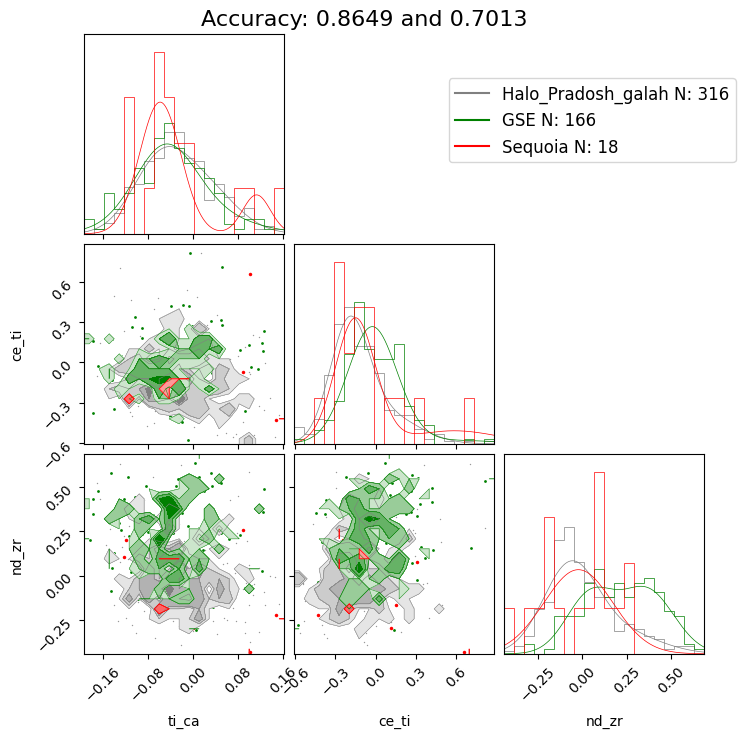

In [41]:
''' MINI CORNER PLOT FOR SPESIFIC GROUP '''

# labels = ['ca_ti', 'ti_ce', 'nd_zr']
e_labels = []
for i in labels:
    e_labels.append('e_' + i)

# for i in range(len(TOP_lables[0])):
    # labels = TOP_lables[0][i]
    # e_labels = TOP_lables[1][i]
    # accuracy_1 = TOP_lables[2][i]
    # accuracy_2 = TOP_lables[3][i]


accuracy_1 = hbvbse['accuracy_GSE_Sequoia'].iloc[0]
accuracy_2 = hbvbse['accuracy_all_3'].iloc[0]
    # accuracy_1 = hbvbse.iloc[0, -1]   # last column
# accuracy_2 = hbvbse.iloc[0, -2]   # second to last column

first_plot = 'Halo_Pradosh_galah' #pick one of the keys in corner_datasets
n_components = 2
vline_and_hline = False

plot_datapoints= True
plot_contours=True
fill_contours=True
plot_density=False

corner_datasets = {
    # "galah_Halo": (galah_Gaia_Halo_new_ratios[labels], galah_Gaia_Halo_new_ratios[e_labels],"grey", 1, 0.8),
    "Halo_Pradosh_galah": (Halo_Pradosh_galah_Gaia[labels], Halo_Pradosh_galah_Gaia[e_labels],"grey", 1, 0.8),

    # "galah_Thickdisk": (thickdisk_galah_Gaia[labels], thickdisk_galah_Gaia[e_labels],"purple", 2.5, 1.0),
    "GSE": (galah_Gaia_GSE_new_ratios[labels], galah_Gaia_GSE_new_ratios[e_labels],"green", 2.0, 1.0),
    "Sequoia": (galah_Gaia_Sequoia_new_ratios[labels], galah_Gaia_Sequoia_new_ratios[e_labels],"red", 2.5, 1.0),
    # "galah_NGC5139": (galah_Gaia_NGC5139_new_ratios[labels], galah_Gaia_NGC5139_new_ratios[e_labels],"blue", 2.5, 1.0),
    # "galah_NGC3201": (galah_Gaia_NGC3201_new_ratios[labels], galah_Gaia_NGC3201_new_ratios[e_labels],"purple", 2.5, 1.0),
    
}

# keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
# cmap = plt.cm.tab10
# colors = cmap(np.linspace(0, 0.8, len(keys)))

# for key, color in zip(keys, colors):
#     df_values, df_errors, _, ms, alpha = corner_datasets[key]
#     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
# # Convert all to values and keep data info

for key in corner_datasets:
    df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

    vals = df_values.to_numpy()
    # vals, mask = filter_constant_columns(vals)
    errs = df_errors.to_numpy()
    row_mask = np.any(np.isfinite(vals), axis=1)
    vals = vals[row_mask]
    errs = errs[row_mask]
    print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
    corner_datasets[key] = (vals, errs, color, ms, alpha)

first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]

    # Compute reasonable plotting ranges using percentiles
ranges = []

for dim in range(first_values.shape[1]):

    # combine all datasets for consistent limits
    combined = []

    for key, (values, errors, color, ms, alpha) in corner_datasets.items():
        combined.append(values[:, dim])

    combined = np.concatenate(combined)

    # remove NaNs/infs
    combined = combined[np.isfinite(combined)]

    # percentile clipping
    low = np.percentile(combined, 1)
    high = np.percentile(combined, 99)

    # optional padding
    padding = 0.05 * (high - low)

    ranges.append((low - padding, high + padding))

fig = corner.corner(
first_values,
labels=labels,
color=first_color,
range = ranges,
data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
plot_datapoints=plot_datapoints,
plot_contours=plot_contours,
fill_contours=fill_contours,
plot_density=plot_density,
# plot_datapoints=False,
# plot_contours=True,
# fill_contours=True,
# plot_density=True,

contour_kwargs={"linewidths": 0.4, "alpha": 1},
fill_contour_kwargs={"alpha": 0.1},
)

ACC_1 = round(accuracy_1, 4)
print(accuracy_1)
ACC_2 = round(accuracy_2, 4)
fig.suptitle(f'Accuracy: {ACC_1} and {ACC_2}', fontsize=16, y=0.98)

ndim = first_values.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

def overlay_gaussian(values, errors, color, n_components):
    for i in range(ndim):
        ax = axes[i, i]
        x = values[:, i]
        sigma_x = errors[:, i]

        mask = np.isfinite(x) & np.isfinite(sigma_x)
        x = x[mask]

        if len(x) > 5:  # need enough points
            # Fit 2-component Gaussian Mixture
            gmm = GaussianMixture(n_components=n_components)
            gmm.fit(x.reshape(-1, 1))

            x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)

            pdf = np.zeros_like(x_grid)

            # Sum the two Gaussians
            for weight, mean, cov in zip(gmm.weights_, gmm.means_, gmm.covariances_):
                sigma = np.sqrt(cov[0][0])
                pdf += weight * norm.pdf(x_grid, mean[0], sigma)

                # (optional) plot individual components
                ax.plot(x_grid,
                        weight * norm.pdf(x_grid, mean[0], sigma),
                        color=color,
                        lw=1,
                        # ls='dashed',
                        ls = "none",
                        alpha=0.7)

            # Plot total mixture
            ax.plot(x_grid, pdf, color=color, lw=0.5)

                #These next couple things will plot the verticle and horizontal lines
            if vline_and_hline == True:
                max_index = np.argmax(pdf)
                peak_x = x_grid[max_index]
                peak_y = pdf[max_index]

                print("Peak x:", peak_x)
                print("Peak pdf:", peak_y)

                # ax.axvline(peak_x, color=color, lw=1)
                for row in range(ndim):

                    if row >= i:

                        ax_col = axes[row, i]

                        ax_col.axvline(
                            peak_x,
                            color=color,
                            lw=1,
                            alpha=0.8
                        )
                
                # draw horizontal line through entire row
                for col in range(ndim):

                    # lower triangle exists
                    if i >= col:

                        ax_row = axes[i, col]

                        ax_row.axhline(
                            peak_x,
                            color=color,
                            lw=1,
                            alpha=0.8
                        )

# Overlay remaining datasets
handles = []
for key, (values, errors, color, ms, alpha) in corner_datasets.items():
    if key != first_plot:
        corner.corner(
            values,
            fig=fig,
            color=color,
            range = ranges,
            data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
            hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
            plot_datapoints=plot_datapoints,
            plot_contours=plot_contours,
            fill_contours=fill_contours,
            plot_density=plot_density,
            contour_kwargs={"linewidths": 0.4, "alpha": 0.8},
            # fill_contour_kwargs={"alpha": 0.1},
            show_titles=(key == "NGC3201"),
        )
    overlay_gaussian(values, errors, color, n_components)
    handles.append(plt.Line2D([0], [0], color = color, label = f'{key} N: {values.shape[0]}'))

fig.legend(handles=handles,
        loc="upper right",
        bbox_to_anchor=(1.0, 0.90),
        #    ncol=len(handles),
        #    frameon=False,
        fontsize=12)


In [ ]:
# ratio_list = galah_gaia_new_element_ratio_list
# ratio_list = S_and_A_rank_visual_ratios
ratio_list = high_acc_mask_table['ratio'].to_list()

n_components = 2


object_list = {
                'GSE': (galah_Gaia_GSE_new_ratios, 'g', 1, 0.5, 0.02),  #df, color, linewidth, alpha, shift_right
                'Sequoia': (galah_Gaia_Sequoia_new_ratios, 'r', 1, 0.5, 0.10),
                'Halo': (galah_Gaia_Halo_new_ratios, 'grey', 1, 0.5, 0.18)
}



for ratio in ratio_list:
    plt.figure(figsize=(10, 6))
    all_values = []

    for key, (df, color, lw, alpha, shift_right) in object_list.items():

        values = df[ratio].to_numpy()
        values = values[np.isfinite(values)]
        all_values.append(values)

        df_copy = df
        num_stars = str(len(df_copy))
        plot_gmm(df_copy[ratio] , f'{key}: N = {num_stars}', color, n_components, maximum_peak = True, shift_right = shift_right)
        plt.hist(df[ratio], density = True, bins  = 30, histtype='step', facecolor = 'none', alpha = alpha, edgecolor=color, linewidth = lw)
        # mean = np.round(np.mean(df[ratio]), 3)
        # plt.axvline(x=mean, color=color, linestyle='--')

    all_values = np.concatenate(all_values)
    low = np.percentile(all_values, 1)
    high = np.percentile(all_values, 99)

    plt.xlim(low, high)

    plt.title(F'Galah {ratio} distribution')
    plt.xlabel(f'[{ratio}]')
    plt.ylabel('density')
    plt.legend()